0.14841818809509277


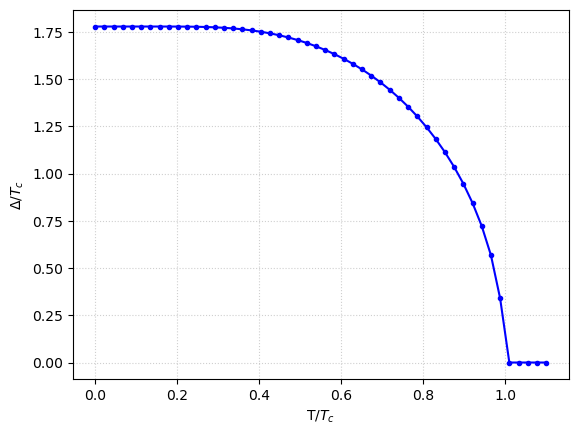

In [11]:
#BCS s-wave
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import quad
import time

kB = 1.0
hbar = 1.0

Tc = 10.0
Theta_D = 100.0
Omega_D = Theta_D * kB

#Delta_0 = 1.7637 * kB * Tc

#V_eff = /1(V*N(E_f))
#V_eff = np.log((Omega_D + np.sqrt(Omega_D**2 + Delta_0**2))/Delta_0)

def bcs_gap_integral_kernel(epsilon, Delta, T):
    E = np.sqrt(epsilon**2 + Delta**2)
    return np.tanh(E/(2 * kB * T))/E

def bcs_gap_integral(Delta, T):
    if Delta < 1e-8:
        Delta = 1e-8 
    integral, err = quad(bcs_gap_integral_kernel, 0, Omega_D, args=(Delta, T))
    return integral

#V_eff = bcs_gap_integral(Delta_0, 0.01)
V_eff = bcs_gap_integral(0, Tc)

def self(Delta, T):
    return V_eff - bcs_gap_integral(Delta, T)

def solve_bcs_gap(T):
    if T >= Tc:
        return 0.0
    T_ratio = T/Tc
    root = fsolve(self, Tc, args = (T))
    return root[0]

start_time = time.time()
T_plot = np.linspace(0.01, Tc*1.1, 50)
Delta_plot = [solve_bcs_gap(T) for T in T_plot]

T_normalized = T_plot/Tc
Delta_plot = np.array(Delta_plot)
Delta_normalized_s_wave = Delta_plot/Tc

plt.plot(T_normalized, Delta_normalized_s_wave, marker='o', markersize=3, linestyle='-', color='b')
plt.xlabel('T/$T_c$')
plt.ylabel(r'$\Delta/T_c$')
plt.grid(True, linestyle=':', alpha=0.6)
end_time = time.time()
print(end_time-start_time)

13.444230318069458


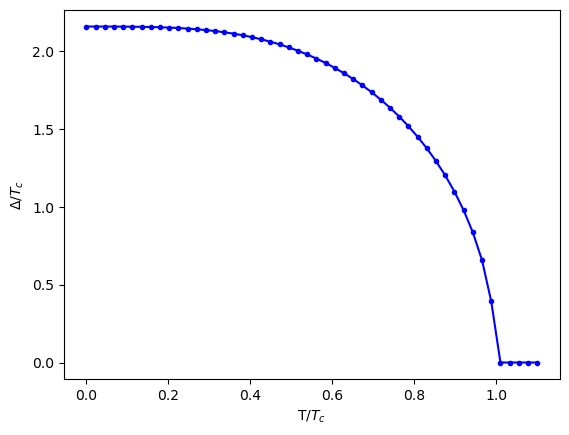

In [12]:
#BCS d-wave
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import quad
import time

kB = 1.0
hbar = 1.0

Tc = 10.0
Theta_D = 100.0
Omega_D = Theta_D * kB

#Delta_0 = 2.14 * kB * Tc

def d_wave_delta(theta, Delta):
    return Delta * np.cos(2*theta)

def d_wave_angle_integral_kernel(theta, epsilon, Delta, T):
    E = np.sqrt(epsilon**2 + d_wave_delta(theta, Delta)**2)
    return np.cos(2*theta)**2 * np.tanh(E/(2 * kB * T))/E

def d_wave_angle_integral(epsilon, Delta, T):
    integral, err = quad(d_wave_angle_integral_kernel, 0, 0.5*np.pi, args=(epsilon, Delta, T), limit=200)
    return 4*integral/(2*np.pi)

def d_wave_integral(Delta, T):
    if Delta < 1e-8:
        Delta = 1e-8 
    integral, err = quad(d_wave_angle_integral, 0, Omega_D, args=(Delta, T))
    return integral

#V_eff = d_wave_integral(Delta_0, 0.01)
V_eff = d_wave_integral(1e-8, Tc)

def self(Delta, T):
    return V_eff - d_wave_integral(Delta, T)

def solve_bcs_gap(T):
    if T >= Tc:
        return 0.0
    T_ratio = T/Tc
    root = fsolve(self, Tc, args = (T))
    return root[0]

start_time = time.time()
T_plot = np.linspace(0.01, Tc*1.1, 50)
Delta_plot = [solve_bcs_gap(T) for T in T_plot]

T_normalized = T_plot/Tc
Delta_plot = np.array(Delta_plot)
Delta_normalized_d_wave = Delta_plot/Tc

plt.plot(T_normalized, Delta_normalized_d_wave, marker='o', markersize=3, linestyle='-', color='b')
plt.xlabel('T/$T_c$')
plt.ylabel(r'$\Delta/T_c$')
end_time = time.time()
print(end_time-start_time)

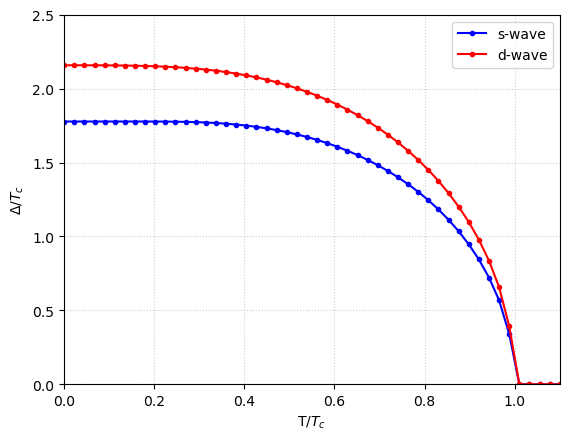

In [13]:
plt.plot(T_normalized, Delta_normalized_s_wave, marker='o', markersize=3, linestyle='-', color='b', label='s-wave')
plt.plot(T_normalized, Delta_normalized_d_wave, marker='o', markersize=3, linestyle='-', color='r', label='d-wave')
plt.xlabel('T/$T_c$')
plt.ylabel(r'$\Delta/T_c$')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.xlim(0, 1.1)
plt.ylim(0, 2.5)
plt.savefig('BCS_gap.png')

Tc = 0.2055870964673496 t
time = 0.3491945266723633 s
2*Delta(0)/Tc = 3.6586


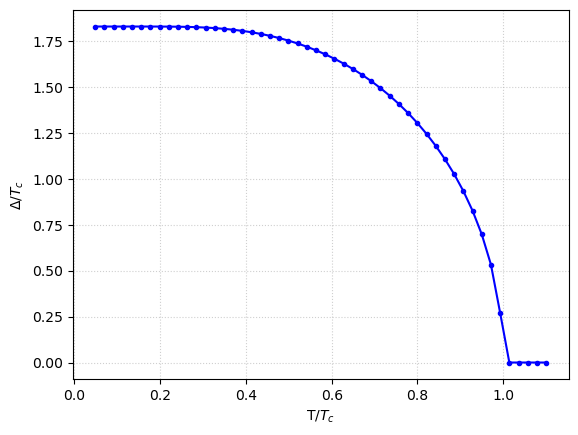

In [8]:
#BCS s-wave on 2D square lattice
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import quad
import time

t = 1.0
t1 = 0.0
t2 = 0.0
g = 2.0*t
mu = 0.0

N = 64
k_points = np.linspace(-np.pi, np.pi, N, endpoint=False)
Kx, Ky = np.meshgrid(k_points, k_points)
Total_K_Points = N**2

def gamma(kx, ky):
    gamma = 1.0
    #gamma = np.cos(kx) - np.cos(ky)
    return gamma

def dispersion(kx, ky):
    ek = -2 * t * (np.cos(kx) + np.cos(ky))
    ek -= 4 * t1 * np.cos(kx) * np.cos(ky)
    ek -= 2 * t2 * (np.cos(2*kx) + np.cos(2*ky))
    ek -= mu
    return ek

def gap_equation_summation(Delta, T):
    if Delta < 1e-8:
        Delta = 1e-8 
    ek = dispersion(Kx, Ky)
    g_k = gamma(Kx, Ky)
    E_k = np.sqrt(ek**2 + Delta**2*g_k**2 + 1e-6)
    f_k = (g_k**2 * np.tanh(E_k / (2 * T)) / (2 * E_k))
    summation = np.sum(f_k) / Total_K_Points
    return g*summation - 1
    
def get_Tc():
    def Tc_equation(T):
        return gap_equation_summation(1e-12, T)    
    Tc = fsolve(Tc_equation, 0.5)
    return Tc[0]

Tc = get_Tc()
print('Tc =', Tc, 't')

def solve_gap(T):
    if T >= Tc:
        return 0.0
    gap = fsolve(gap_equation_summation, Tc, args = (T))
    return gap[0]

start_time = time.time()
T_plot = np.linspace(0.01, Tc*1.1, 50)
Delta_plot = [solve_gap(T) for T in T_plot]

T_normalized = T_plot/Tc
Delta_plot = np.array(Delta_plot)
Delta_normalized_s_wave = Delta_plot/Tc

plt.plot(T_normalized, Delta_normalized_s_wave, marker='o', markersize=3, linestyle='-', color='b')
plt.xlabel('T/$T_c$')
plt.ylabel(r'$\Delta/T_c$')
plt.grid(True, linestyle=':', alpha=0.6)
end_time = time.time()
print('time =', end_time-start_time, 's')

Delta_0 = fsolve(gap_equation_summation, Tc, args=(1e-4,))[0]
print(f"2*Delta(0)/Tc = {2 * Delta_0 / Tc:.4f}")

In [9]:
Delta_0

0.37608302672647703

Tc = 0.399731476082245 t
time = 0.17541003227233887 s
2*Delta(0)/Tc = 2.4100


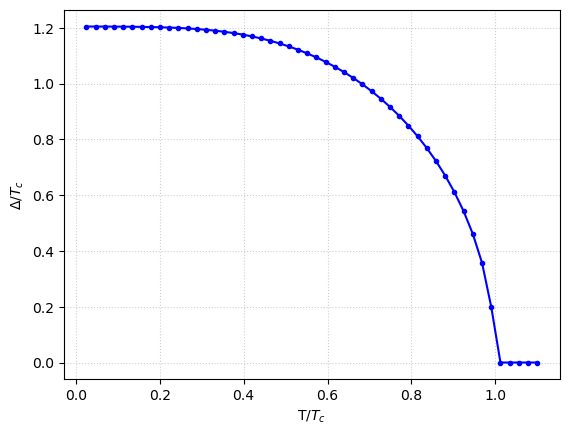

In [1]:
#BCS d-wave on 2D square lattice
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.integrate import quad
import time

t = 1.0
t1 = 0.0
t2 = 0.0
g = 2.0*t
mu = 0.0

N = 64
k_points = np.linspace(-np.pi, np.pi, N, endpoint=False)
Kx, Ky = np.meshgrid(k_points, k_points)
Total_K_Points = N**2

def gamma(kx, ky):
    #gamma = 1.0
    gamma = np.cos(kx) - np.cos(ky)
    return gamma

def dispersion(kx, ky):
    ek = -2 * t * (np.cos(kx) + np.cos(ky))
    ek -= 4 * t1 * np.cos(kx) * np.cos(ky)
    ek -= 2 * t2 * (np.cos(2*kx) + np.cos(2*ky))
    ek -=mu
    return ek

def gap_equation_summation(Delta, T):
    if Delta < 1e-8:
        Delta = 1e-8 
    ek = dispersion(Kx, Ky)
    g_k = gamma(Kx, Ky)
    E_k = np.sqrt(ek**2 + Delta**2*g_k**2 + 1e-6)
    f_k = (g_k**2 * np.tanh(E_k / (2 * T)) / (2 * E_k))
    summation = np.sum(f_k) / Total_K_Points
    return g*summation - 1
    
def get_Tc():
    def Tc_equation(T):
        return gap_equation_summation(1e-12, T)    
    Tc = fsolve(Tc_equation, 0.5)
    return Tc[0]

Tc = get_Tc()
print('Tc =', Tc, 't')

def solve_gap(T):
    if T >= Tc:
        return 0.0
    gap = fsolve(gap_equation_summation, Tc, args = (T))
    return gap[0]

start_time = time.time()
T_plot = np.linspace(0.01, Tc*1.1, 50)
Delta_plot = [solve_gap(T) for T in T_plot]

T_normalized = T_plot/Tc
Delta_plot = np.array(Delta_plot)
Delta_normalized_s_wave = Delta_plot/Tc

plt.plot(T_normalized, Delta_normalized_s_wave, marker='o', markersize=3, linestyle='-', color='b')
plt.xlabel('T/$T_c$')
plt.ylabel(r'$\Delta/T_c$')
plt.grid(True, linestyle=':', alpha=0.6)
end_time = time.time()
print('time =', end_time-start_time, 's')

Delta_0 = fsolve(gap_equation_summation, Tc, args=(1e-4,))[0]
print(f"2*Delta(0)/Tc = {2 * Delta_0 / Tc:.4f}")

In [2]:
Delta_0

0.48167772625733135